In [45]:
# Import Statements
import os

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


In [46]:
def load_metadata():
    '''
    Load and preprocess the metadata by reading the Excel file, generating full paths, and implementing validation removals with any rows where the file does not exist or the melanoma label is missing.

    Returns:
        metadata_df: DataFrame containing the metadata
    '''

    # ---------------------------------
    # Path to the Image Directory: UPDATE PATH AS PER YOUR FILE DIRECTORY!
    #----------------------------------
    image_dir = 'C:\\Users\\User1\\Desktop\\SEGP\\midasmultimodalimagedatasetforaibasedskincancer\\'

    metadata_df = pd.read_excel('release_midas.xlsx') 
    metadata_df['full_path'] = metadata_df['midas_file_name'].apply(
        lambda x: os.path.join(image_dir, x)
    )                                                                               # Full Path Generation

    metadata_df = metadata_df[metadata_df['full_path'].apply(os.path.exists)]       # Validation Check | Removes any rows where the file does not exist
    metadata_df = metadata_df[metadata_df['midas_melanoma'].notna()].copy()         # Removes any rows where the melanoma label is missing.
    metadata_df = metadata_df[metadata_df['midas_path'].notna()].copy()             # Validation Check | Removes any rows where the pathology label is missing.

    metadata_df['label'], label_names = pd.factorize(metadata_df['midas_path'])     # Label Encoding
    return metadata_df

metadata_df = load_metadata()

print(metadata_df['label'])

0       0
1       0
2       0
3       1
4       1
       ..
3405    8
3406    8
3413    1
3414    1
3415    1
Name: label, Length: 2833, dtype: int64


In [47]:
def load_image(full_path, label):
    '''
    Load and preprocess an image by reading, decoding it into the RGB spectrum, resizing, and converting it into a tensor file.

    Parameters:
        full_path: Path to the image file
        label: Label of the image

    Returns:
        image: Preprocessed image
        label: Label of the image
    '''
    image = tf.io.read_file(full_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = tf.image.convert_image_dtype(image, tf.float32)                     # Converts the image to a float32 tensor [0..1]
    return image, label

In [48]:
def split_data():
    # Split the DataFrame first
    train_df, temp_df = train_test_split(
        metadata_df, 
        test_size=0.30,  # 30% for val + test
        random_state=42,
        stratify=metadata_df['label']  # Ensures balanced splits
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,  # Split the 30% equally
        random_state=42,
        stratify=temp_df['label']
    )
    return train_df, val_df, test_df


In [49]:
# Create datasets from each DataFrame
def create_dataset(df, batch_size=64, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((df['full_path'].values, df['label'].values))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1024)

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_dataset(train_df, shuffle=True)
val_dataset = create_dataset(val_df, shuffle=False)
test_dataset = create_dataset(test_df, shuffle=False)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Training samples: 2188
Validation samples: 469
Test samples: 469


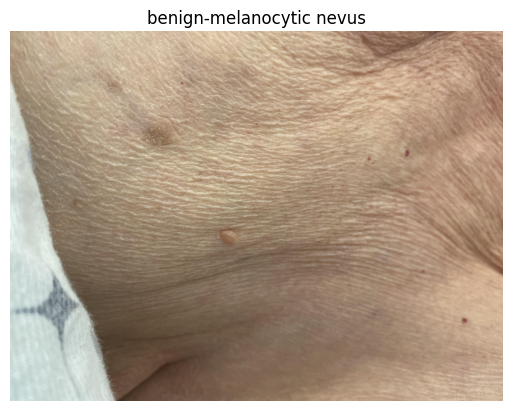


Missing values:
Unnamed: 0                 0
midas_record_id            0
midas_file_name            0
midas_iscontrol            0
midas_distance             0
midas_location             0
midas_path                 0
midas_pathreport           0
midas_gender               0
midas_age                  0
midas_fitzpatrick          6
midas_melanoma             0
midas_ethnicity            0
midas_race                 0
clinical_impression_1     12
clinical_impression_2    209
clinical_impression_3    877
length_(mm)                8
width_(mm)                 8
full_path                  0
label                      0
dtype: int64


In [ ]:
# Image Verification Check
def view_image(i):
    i=6
    image = plt.imread(metadata_df['full_path'][i])
    plt.imshow(image)
    plt.title(metadata_df['midas_path'][i])
    plt.axis('off')
    plt.show()

view_image(6)
    
print(f"\nMissing values:\n{metadata_df.isnull().sum()}")


In [52]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 0


In [ ]:
# Model Architecture [Mobile M]

# Model Training & Testing

# Main Function